In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import scipy.stats as sts
import astropy.units as u
from astropy.constants import G,M_sun,kpc
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import matplotlib.colors as mcol
import matplotlib.cm as mcm
from matplotlib import ticker
import scipy.optimize as sopt
from sim_read import *

plt.style.use('./presentation.mplstyle')

In [2]:
gls = sim(exsub_fields=['SubhaloMass'])
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [3]:
massive_gal,dwarf_gal = dwf_select(gls.sub.mst)
all_gal = np.array([*dwarf_gal,*massive_gal])

sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

1494 10829
1494 10829
-8.346120696830761 -0.17679571397785238


In [4]:

h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5,hfloor=10):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,thresh,floor)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
    back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
    back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]
    dhp,mdb = [[],[],[]],[[],[],[]]

    all_gal_pos =  gls.sub.SubhaloPos[all_gal,:]
    massive_gal_pos = gls.sub.SubhaloPos[massive_gal,:] 

    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        blh = (np.where(j==back_gal)[0])[0]
        if gls.hst.group_m200[lh]>=hfloor and gls.hst.group_m200[lh]<11.5 and gls.sub.mst[j]<thresh and gls.sub.mst[j]>floor:
                #dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                    
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
                          
                dhost[2].append(dist[0])
                llt[2].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
            
                dhp[2].append(ind[0])
                mdb[2].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
                    
                #dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                dist0 = dconv*np.sort(rall)[:5]
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

    dwarf_gal = np.setdiff1d(dwarf_gal,back_gal)
    
    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[dwarf_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        if gls.hst.group_m200[lh]>=hfloor and gls.hst.group_m200[lh]<11.5:
            dw_mem = dwarf_gal[np.where(host_mem==i)[0]]

            stellar_sort = np.argsort(gls.sub.mst[dw_mem])
            cen = dw_mem[stellar_sort[-1]]

            if len(dw_mem)>=1 and gls.sub.mst[gls.hst.GroupFirstSub[lh]]<thresh:
                
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]

                ind = massive_gal[ind]  
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])

                dhost[0].append(dist[0])
                llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[0].append(lh)
                llg[0].append(cen)
                
                dhp[0].append(ind[0])
                mdb[0].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
                
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist0 = dconv*np.sort(rall)[:5]
                llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(dw_mem)>1:
                    for j in dw_mem[stellar_sort[:-1]]:
                        rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]

                        ind = massive_gal[ind]  
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
    
                        dhost[1].append(dist[0])
                        llt[1].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                        llh[1].append(lh)
                        llg[1].append(j)
                        
                        dhp[1].append(ind[0])
                        mdb[1].append(ind[np.argmax(MD_mass - 3*np.log10(dist))])
    
                        rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist0 = dconv*np.sort(rall)[:5]
                        llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                    
        
    return llt,llh,llg,llr,dhost,dhp,mdb


In [5]:
llt,llh,llg,llr,dhost,dhp,mdb = samp_selc(hfloor=9)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll,np.sum(N_lll))
bin_mk = ['o','D','s']

1494 10829
12323 0.098584
[5003, 465, 375] 5843


In [6]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
m200_a = gls.hst.group_m200[llh_a]
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
llr_a = np.log10(np.array([r for i in range(3) for r in llr[i]])) - np.log10(0.142904)

ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])

Nll = len(llh_a)

llg_c = np.array([m for i in range(2) for m in llg[i]])
mst_c = np.array([m for i in range(2) for m in gls.sub.mst[llg[i]]])
llt_c = np.array([t for i in range(2) for t in llt[i]])
llh_c = np.array([h for i in range(2) for h in llh[i]])
m200_c = gls.hst.group_m200[llh_c]
dhost_c = np.array([d for i in range(2) for d in dhost[i]])
llr_c = np.log10(np.array([r for i in range(2) for r in llr[i]])) - np.log10(0.142904)

ssfr_c = np.array([s for i in range(2) for s in gls.sub.ssfr[llg[i]]])
#qnc_c = 1-np.heaviside(ssfr_c-(sfms_intercept -1 + sfms_slope*np.array(mst_c)),1)
Nllc = len(llh_c)

dhp_a = np.array([t for i in range(3) for t in dhp[i]])
mdb_a = np.array([h for i in range(3) for h in mdb[i]])

dhp_c = np.array([t for i in range(2) for t in dhp[i]])
mdb_c = np.array([h for i in range(2) for h in mdb[i]])

#qnc_a = 1-np.heaviside(ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a)),1)

x_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],0]])*dconv - 25
y_a = np.array([y for i in range(3) for y in gls.sub.SubhaloPos[llg[i],1]])*dconv - 25
z_a = np.array([z for i in range(3) for z in gls.sub.SubhaloPos[llg[i],2]])*dconv - 25

In [7]:
bin_stellar = np.arange(9.5,11.5,0.2)

dg1 = massive_gal[np.where(gls.sub.ssfr[massive_gal]>-15)[0]]
bin_med, bin_edg, bin_n = sts.binned_statistic(gls.sub.mst[dg1],gls.sub.ssfr[dg1], statistic='median', bins=bin_stellar)

res = sts.linregress(bin_edg[:-1],bin_med)
print(res.intercept,res.slope)


#host_bins = [np.where(m200_a<11.5)[0],np.where(m200_a>=11.5)[0]]
#bin_cols = ['teal','firebrick']

#dw_samp = np.where(m200_a<11.5)[0]

-4.043278702457738 -0.620927639813141


Text(0, 0.5, '$f(<\\Theta_1)$')

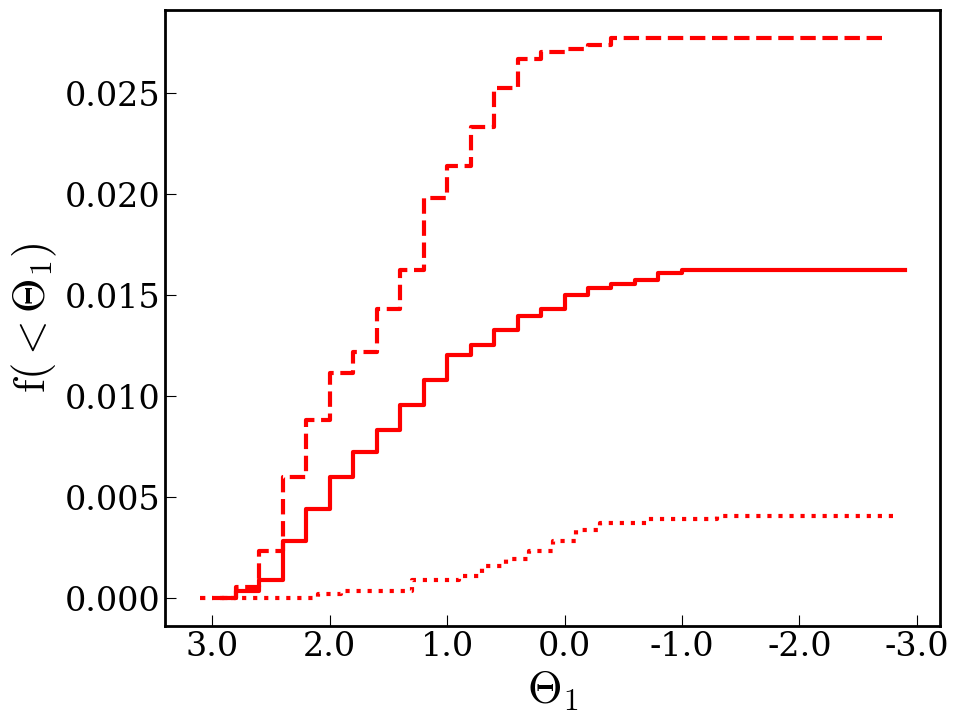

In [8]:
fig,ax=plt.subplots(figsize=(10,8),sharex=True)

bin_ls = ['-',':','--']
llt_bins = np.linspace(-3,3,31)

for k in range(3):
    qnc_a = gls.sub.ssfr[llg[k]]-(sfms_intercept -1 + sfms_slope*np.array(gls.sub.mst[llg[k]]))
    red = np.where(qnc_a<0)[0]

    
    bin_sat, bin_edg = np.histogram(np.array(llt[k])[red],bins=llt_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax.step(bin_edg[:-1],np.cumsum(bin_sat[::-1])[::-1]/np.sum(N_lll),color='red',ls=bin_ls[k],lw=3,where='mid')
'''    
custom_lines = [Line2D([0], [0],lw=3,ls=bin_ls[0], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[1], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[2], color='black')]
leg=Legend(ax,custom_lines,[r'$centrals$',r'$group\ satellites$',r'$backsplash$'],loc='lower left',fontsize=20,framealpha=0.8,frameon=True)
ax.add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax,custom_lines,[r'$quenched$',r'$star-forming$'],loc='upper right',fontsize=20,framealpha=0.8,frameon=True)
ax.add_artist(leg)
'''
ax.invert_xaxis()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))

ax.set_xlabel(r'$\Theta_1$',fontsize=32)
ax.set_ylabel(r'$f(<\Theta_1)$',fontsize=32)
#plt.savefig('dwarf_dhost_cumul.pdf',bbox_inches='tight')

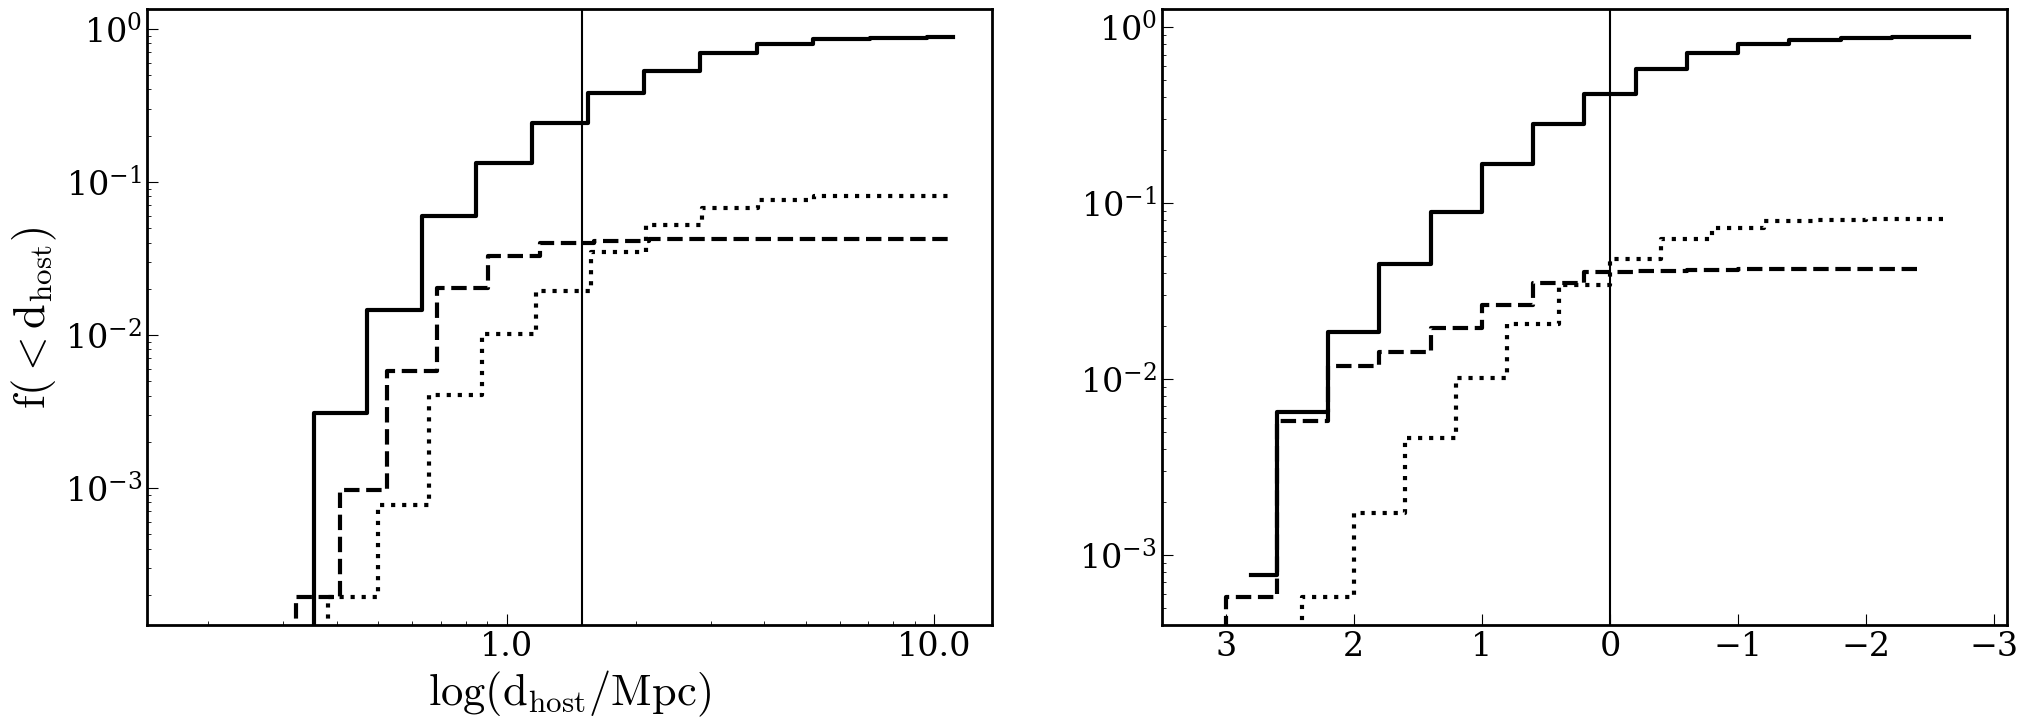

In [31]:
fig,ax=plt.subplots(1,2,figsize=(24,8))

dhst_bins = np.logspace(np.log10(0.15),np.log10(15),16)
llt_bins = np.linspace(-3,3,16)

bin_ls = ['-',':','--']

for k in range(3):
    bin_sat, bin_edg = np.histogram(dhost[k],bins=dhst_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[0].step(bin_edg[:-1],np.cumsum(bin_sat)/np.sum(N_lll),color='black',ls=bin_ls[k],lw=3,where='mid')

    bin_sat, bin_edg = np.histogram(llt[k],bins=llt_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[1].step(bin_edg[:-1],np.cumsum(bin_sat[::-1])[::-1]/np.sum(N_lll),color='black',ls=bin_ls[k],lw=3,where='mid')
'''
custom_lines = [Line2D([0], [0],lw=3,ls=bin_ls[0], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[1], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[2], color='black')]
leg=Legend(ax,custom_lines,[r'$centrals$',r'$group\ satellites$',r'$backsplash$'],loc='lower left',fontsize=20,framealpha=0.8,frameon=True)
ax.add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax,custom_lines,[r'$quenched$',r'$star-forming$'],loc='upper right',fontsize=20,framealpha=0.8,frameon=True)
ax.add_artist(leg)
'''
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[1].invert_xaxis()
ax[0].axvline(1.5,color='black')
ax[1].axvline(0,color='black')
ax[0].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))

ax[0].set_xlabel(r'$log(d_{host}/ Mpc)$',fontsize=32)
ax[0].set_ylabel(r'$f(<d_{host})$',fontsize=32)
plt.savefig('dwarf_dhost_cumul.pdf',bbox_inches='tight')

0 577 181
1 4657 428
All 0 dhost [       nan 0.34104901 0.13306711 0.02280271 0.        ]
All 0 tidal [       nan 0.84002914 0.59393299 0.10339469        nan]
All 1 dhost [       nan 0.14464123 0.0426057  0.01112446 0.0034019 ]
All 1 tidal [       nan 0.52447559 0.39388855 0.03560505 0.        ]
0 519 93
1 4541 315
No Backsplash 0 dhost [0.15209968 0.06802759 0.01377098 0.00709009 0.        ]
No Backsplash 0 tidal [       nan 0.31455207 0.0535427  0.                nan]
No Backsplash 1 dhost [0.07777448 0.0290854  0.01578194 0.0053787  0.0040547 ]
No Backsplash 1 tidal [       nan 0.18489597 0.07437565 0.                nan]


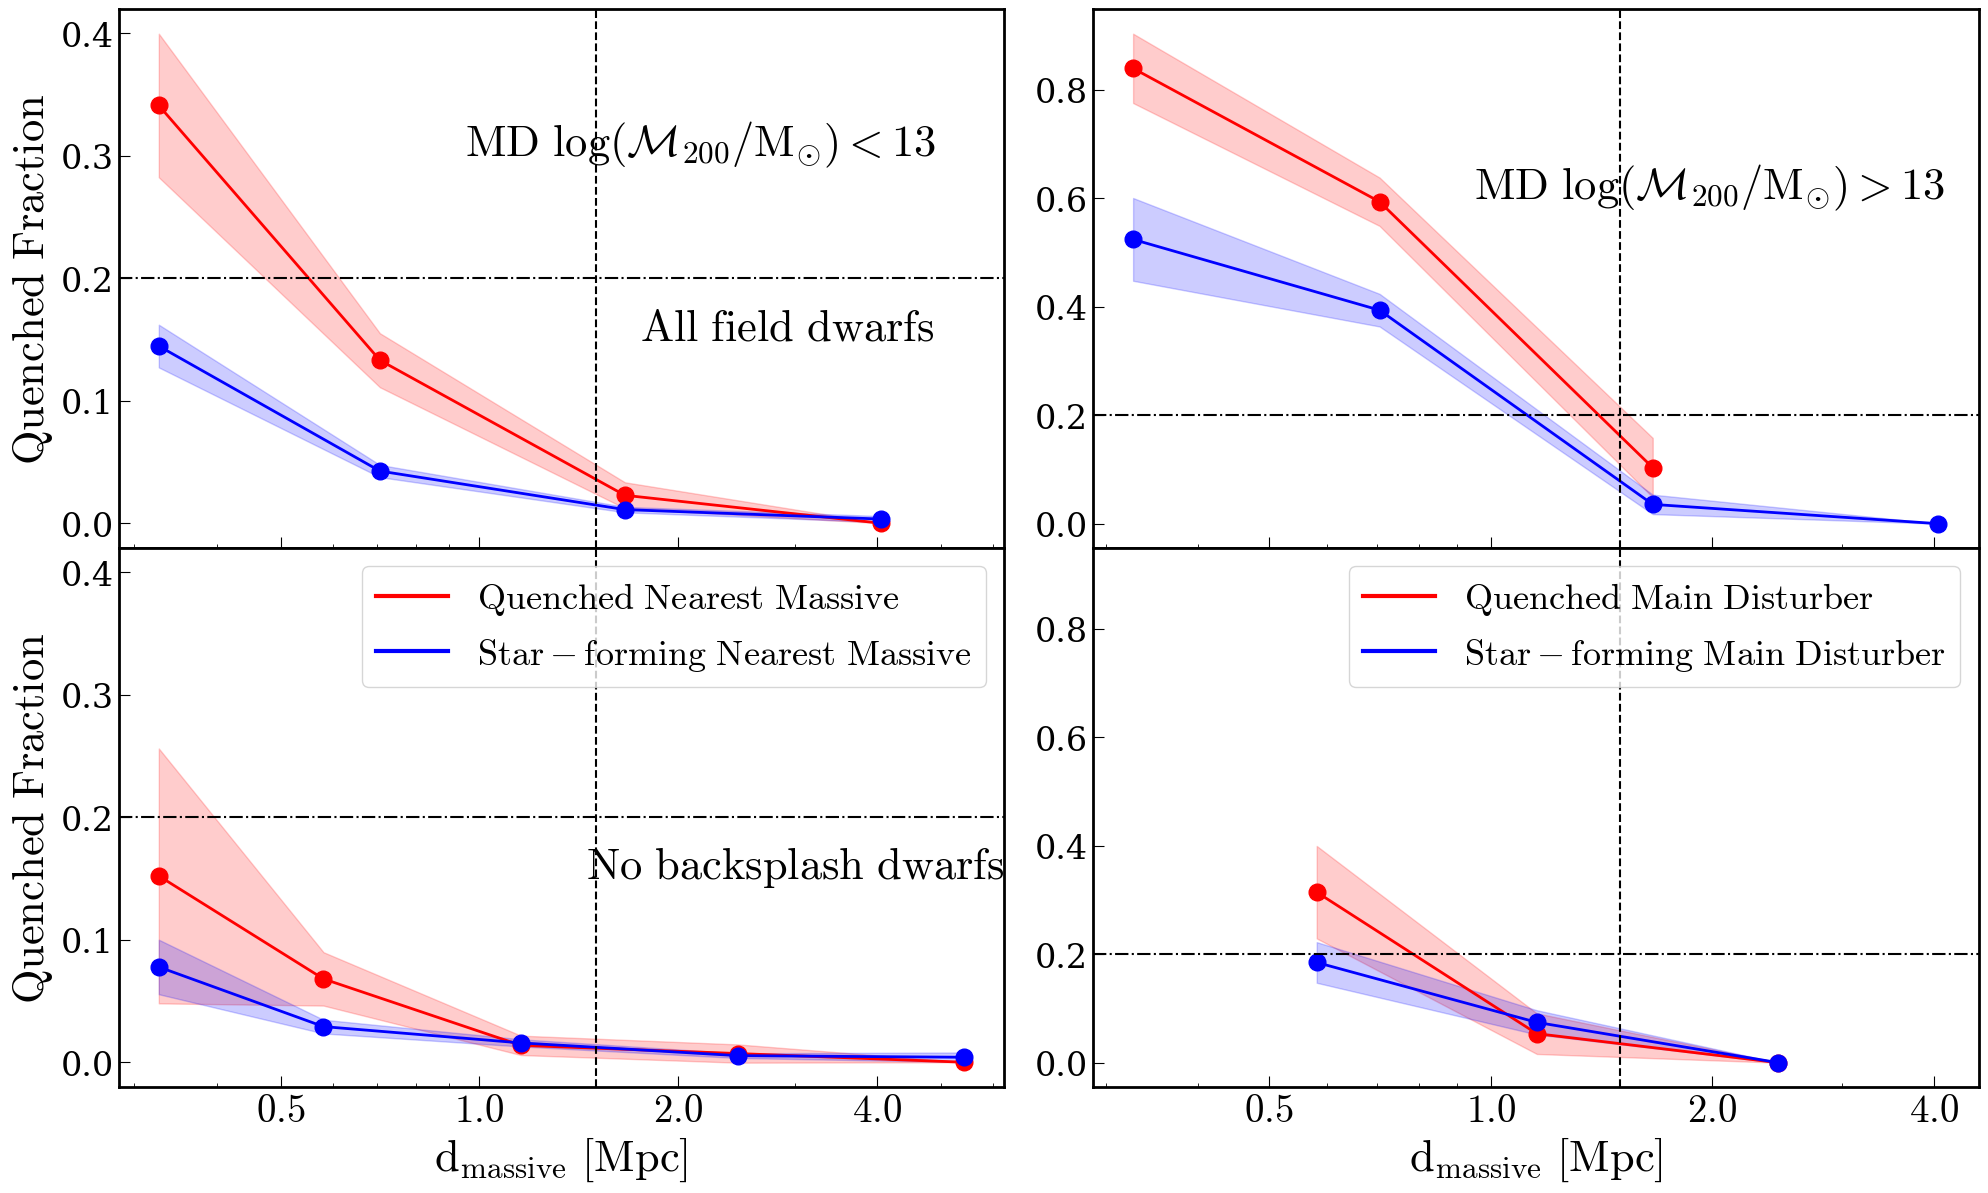

In [16]:
fig,ax=plt.subplots(2,2,figsize=(24,14),sharey='col',sharex='col')

bin_cols=['red','blue']
tracer_bins1 = [np.logspace(np.log10(0.1),np.log10(10),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

Nbtsp = 1000

dhmd_ssfr = gls.sub.ssfr[dhp_a]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_a])
md_m200 = gls.hst.group_m200[gls.sub.SubhaloGrNr[mdb_a]]
qsfhost = [np.where((dhmd_ssfr<0)&(m200_a<11.5)&(md_m200<13))[0],np.where((dhmd_ssfr<0)&(m200_a<11.5)&(md_m200>=13))[0],np.where((dhmd_ssfr>=0)&(m200_a<11.5)&(md_m200<13))[0],np.where((dhmd_ssfr>=0)&(m200_a<11.5)&(md_m200>=13))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_b = [dhost_a[i] for i in boot]
            mst_b = [gls.sub.mst[llg_a[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_a[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            dhost_b = [dhost_a[i] for i in boot]
            mst_b = [gls.sub.mst[llg_a[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_a[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('All',j,'dhost',boot_val)

    ax[0,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('All',j,'tidal',boot_val)

    ax[0,1].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,1].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

tracer_bins1 = [np.logspace(np.log10(0.2),np.log10(12),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

dhmd_ssfr = gls.sub.ssfr[dhp_c]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_c])
md_m200 = gls.hst.group_m200[gls.sub.SubhaloGrNr[mdb_c]]
qsfhost = [np.where((dhmd_ssfr<0)&(m200_c<11.5)&(md_m200<13))[0],np.where((dhmd_ssfr<0)&(m200_c<11.5)&(md_m200>=13))[0],np.where((dhmd_ssfr>=0)&(m200_c<11.5)&(md_m200<13))[0],np.where((dhmd_ssfr>=0)&(m200_c<11.5)&(md_m200>=13))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_b = [dhost_c[i] for i in boot]
            mst_b = [gls.sub.mst[llg_c[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_c[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            dhost_b = [dhost_c[i] for i in boot]
            mst_b = [gls.sub.mst[llg_c[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_c[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'dhost',boot_val)

    ax[1,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'tidal',boot_val)

    ax[1,1].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,1].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)


    for k in range(2):
        ax[j,k].axhline(0.2,color='black',ls='-.')

    ax[j,0].axvline(1.5,color='black',ls='--')
    ax[j,1].axvline(1.5,color='black',ls='--')
    #ax[j,1].axvline(0,color='black',ls='--')

    ax[j,0].set_ylabel(r'$Quenched\ Fraction$',fontsize=32)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)

xticks = [0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]
for j in range(2):
    ax[0,j].set_xscale('log')
    ax[1,j].set_xscale('log')
    ax[1,j].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=32)
    
    ax[1,j].set_xticks(xticks, labels=xlabels,fontsize=28)

ax[0,0].text(1.75,0.15,r'$All\ field\ dwarfs$',fontsize=32)
ax[1,0].text(1.45,0.15,r'$No\ backsplash\ dwarfs$',fontsize=32)
ax[0,0].text(0.95,0.3,r'$MD\ {\rm log}(\mathcal{M}_{200}/M_{\odot})<13$',fontsize=32)
ax[0,1].text(0.95,0.6,r'$MD\ {\rm log}(\mathcal{M}_{200}/M_{\odot})>13$',fontsize=32)
#ax[1,1].text(2,0.35,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[1,0],custom_lines,[r'$Quenched\ Nearest\ Massive$',r'$Star-forming\ Nearest\ Massive$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[1,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[1,1],custom_lines,[r'$Quenched\ Main\ Disturber$',r'$Star-forming\ Main\ Disturber$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[1,1].add_artist(leg)

plt.subplots_adjust(wspace=0.1,hspace=0.0)
plt.savefig('quench_conformity2.pdf',bbox_inches='tight')


0 758 1142
1 5085 4701
All 0 dhost [       nan 0.49557614 0.27897412 0.03354646 0.        ]
All 0 tidal [       nan 0.01223928 0.05336761 0.21642996 0.28931837]
All 1 dhost [       nan 0.1788832  0.09332704 0.01247562 0.00337657]
All 1 tidal [0.         0.00428541 0.02793697 0.08142659 0.35873893]
0 612 1023
1 4856 4445
No Backsplash 0 dhost [0.25419212 0.11074607 0.0197157  0.00626689 0.        ]
No Backsplash 0 tidal [       nan 0.01250221 0.01383023 0.0524677  0.11246941]
No Backsplash 1 dhost [0.08260903 0.04578818 0.01997665 0.00513582 0.00384521]
No Backsplash 1 tidal [0.         0.00439467 0.01278205 0.02777732 0.15191383]


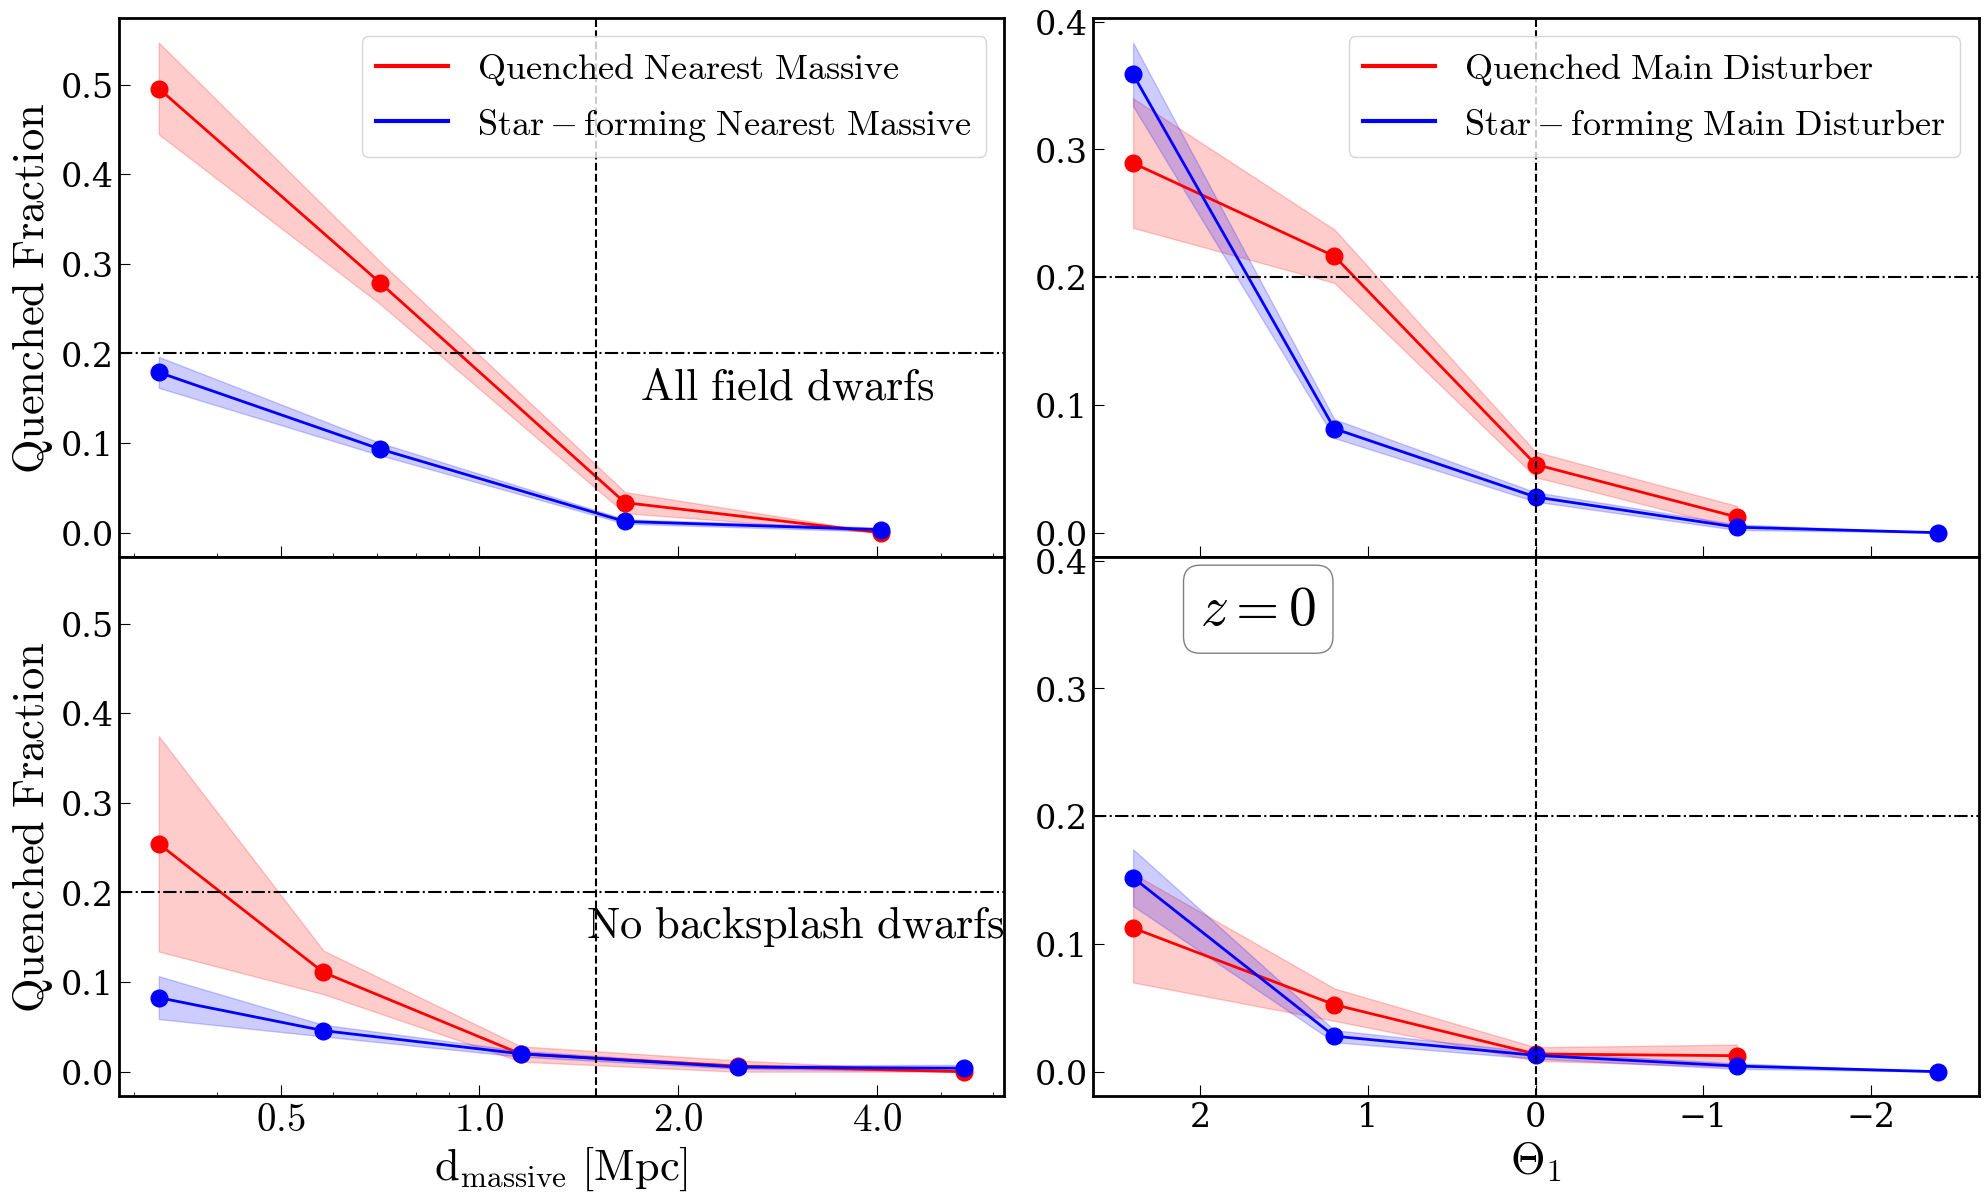

In [9]:
fig,ax=plt.subplots(2,2,figsize=(24,14),sharey='col',sharex='col')

bin_cols=['red','blue']
tracer_bins1 = [np.logspace(np.log10(0.1),np.log10(10),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

Nbtsp = 1000

dhmd_ssfr = [gls.sub.ssfr[dhp_a]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_a]),gls.sub.ssfr[mdb_a]-(res.intercept -1 + res.slope*gls.sub.mst[mdb_a])]
qsfhost = [np.where((dhmd_ssfr[0]<0)&(m200_a<11.5))[0],np.where((dhmd_ssfr[1]<0)&(m200_a<11.5))[0],np.where((dhmd_ssfr[0]>=0)&(m200_a<11.5))[0],np.where((dhmd_ssfr[1]>=0)&(m200_a<11.5))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_b = [dhost_a[i] for i in boot]
            mst_b = [gls.sub.mst[llg_a[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_a[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            llt_b = np.array([llt_a[i] for i in boot])
            mst_b = [gls.sub.mst[llg_a[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_a[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins1[1])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('All',j,'dhost',boot_val)

    ax[0,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('All',j,'tidal',boot_val)

    ax[0,1].plot(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[0,1].fill_between(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

tracer_bins1 = [np.logspace(np.log10(0.2),np.log10(12),6),np.linspace(-3,3,6)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]

dhmd_ssfr = [gls.sub.ssfr[dhp_c]-(res.intercept -1 + res.slope*gls.sub.mst[dhp_c]),gls.sub.ssfr[mdb_c]-(res.intercept -1 + res.slope*gls.sub.mst[mdb_c])]
qsfhost = [np.where((dhmd_ssfr[0]<0)&(m200_c<11.5))[0],np.where((dhmd_ssfr[1]<0)&(m200_c<11.5))[0],np.where((dhmd_ssfr[0]>=0)&(m200_c<11.5))[0],np.where((dhmd_ssfr[1]>=0)&(m200_c<11.5))[0]]

boot_qnc = np.zeros((4,Nbtsp,5))
for j in range(2):
    print(j,len(qsfhost[2*j]),len(qsfhost[2*j+1]))
    for m in range(Nbtsp):
            boot = npr.choice(qsfhost[2*j],len(qsfhost[2*j]),replace=True)
    
            dhost_b = [dhost_c[i] for i in boot]
            mst_b = [gls.sub.mst[llg_c[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_c[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)
    
            bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_b,qnc_b,statistic='mean', bins=tracer_bins1[0])
            boot_qnc[2*j,m,:] = bin_qnc

            boot = npr.choice(qsfhost[2*j+1],size=len(qsfhost[2*j+1]),replace=True)
    
            llt_b = np.array([llt_c[i] for i in boot])
            mst_b = [gls.sub.mst[llg_c[i]] for i in boot]
            ssfr_b = [gls.sub.ssfr[llg_c[i]] for i in boot]
        
            qnc_b = 1-np.heaviside(ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b)),1)

            bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_b,qnc_b,statistic='mean', bins=tracer_bins1[1])
            boot_qnc[2*j+1,m,:] = bin_qnc
        
for j in range(2):
    boot_val = np.mean(boot_qnc[2*j,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'dhost',boot_val)

    ax[1,0].plot(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,0].fill_between(tracer_bins1[0][:-1]+tracer_bw1[0],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)

    boot_val = np.mean(boot_qnc[2*j+1,:,:],axis=0)
    boot_err = np.std(boot_qnc[2*j+1,:,:],axis=0,ddof=1)

    print('No Backsplash',j,'tidal',boot_val)

    ax[1,1].plot(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val,lw=2,marker=bin_mk[0],color=bin_cols[j],markersize=12)
    ax[1,1].fill_between(tracer_bins1[1][:-1]+tracer_bw1[1],boot_val-boot_err,boot_val+boot_err,color=bin_cols[j],alpha=0.2)


    for k in range(2):
        ax[j,k].axhline(0.2,color='black',ls='-.')

    ax[j,0].axvline(1.5,color='black',ls='--')
    ax[j,1].axvline(0,color='black',ls='--')

    ax[j,0].set_ylabel(r'$Quenched\ Fraction$',fontsize=32)
#ax[0].set_ylabel(r'$Quenching\ Efficiency$',fontsize=30)

ax[0,0].set_xscale('log')
ax[1,0].set_xscale('log')
ax[1,0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=32)
ax[1,1].set_xlabel(r'$\Theta_1$',fontsize=32)
ax[0,1].invert_xaxis()
xticks = [0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]
ax[1,0].set_xticks(xticks, labels=xlabels,fontsize=28)

ax[0,0].text(1.75,0.15,r'$All\ field\ dwarfs$',fontsize=32)
ax[1,0].text(1.45,0.15,r'$No\ backsplash\ dwarfs$',fontsize=32)
ax[1,1].text(2,0.35,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[0,0],custom_lines,[r'$Quenched\ Nearest\ Massive$',r'$Star-forming\ Nearest\ Massive$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[0,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax[0,1],custom_lines,[r'$Quenched\ Main\ Disturber$',r'$Star-forming\ Main\ Disturber$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[0,1].add_artist(leg)

plt.subplots_adjust(wspace=0.1,hspace=0.0)
plt.savefig('quench_conformity.pdf',bbox_inches='tight')


443 401 413
80 5003
18 465
274 375


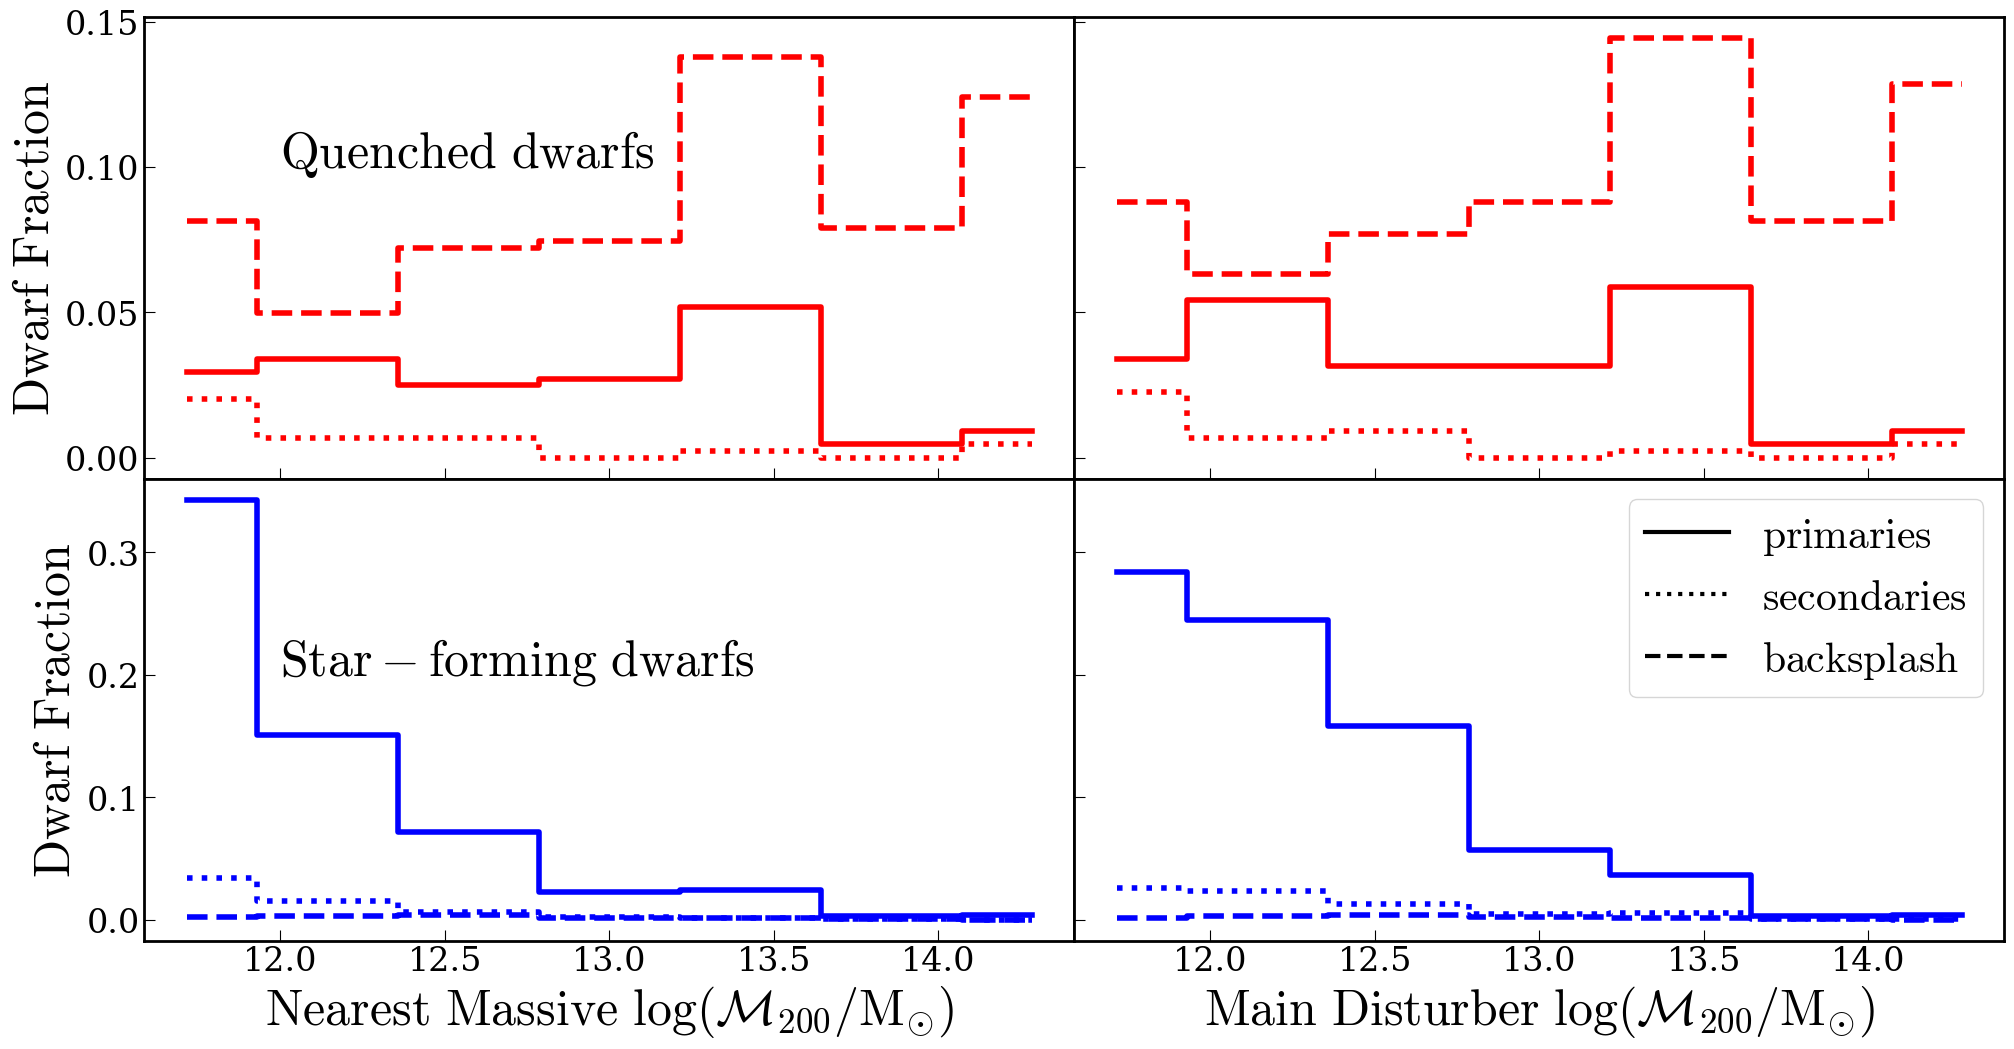

In [20]:
fig,ax=plt.subplots(2,2,figsize=(24,12),sharex='col',sharey='row')

bin_ls = ['-',':','--']
mh_bins = np.linspace(11.5,14.5,8)
mh_bw = 0.5*(mh_bins[1]-mh_bins[0])

qnc_a = ssfr_a-(sfms_intercept -1 + sfms_slope*mst_a)
red_a = np.where(qnc_a<0)[0]
blue_a = np.where(qnc_a>0)[0]

red_ind = np.where((qnc_a<0)&(dhost_a<1.5))[0]
red_int = np.where((qnc_a<0)&(llt_a>0))[0]

print(len(red_a),len(red_ind),len(red_int))

for k in range(3):
    mst_b = np.array(gls.sub.mst[llg[k]])
    ssfr_b = np.array(gls.sub.ssfr[llg[k]])
    m200_b = gls.hst.group_m200[llh[k]]
    qnc_b  = ssfr_b-(sfms_intercept -1 + sfms_slope*np.array(mst_b))
    
    red = np.where(qnc_b<0)[0]
       
    m200_dhp = gls.hst.group_m200[gls.sub.SubhaloGrNr[dhp[k]][red]]
    m200_mdb = gls.hst.group_m200[gls.sub.SubhaloGrNr[mdb[k]][red]]
    
    bin_sat, bin_edg = np.histogram(m200_dhp,bins=mh_bins)
    print(np.sum(bin_sat),N_lll[k])
    ax[0,0].step(bin_edg[:-1]+mh_bw,bin_sat/len(red_a),color='red',ls=bin_ls[k],lw=4,where='mid')

    bin_sat, bin_edg = np.histogram(m200_mdb,bins=mh_bins)
    ax[0,1].step(bin_edg[:-1]+mh_bw,bin_sat/len(red_a),color='red',ls=bin_ls[k],lw=4,where='mid')

    blue = np.where(qnc_b>0)[0]
       
    m200_dhp = gls.hst.group_m200[gls.sub.SubhaloGrNr[dhp[k]][blue]]
    m200_mdb = gls.hst.group_m200[gls.sub.SubhaloGrNr[mdb[k]][blue]]
    
    bin_sat, bin_edg = np.histogram(m200_dhp,bins=mh_bins)
    ax[1,0].step(bin_edg[:-1]+mh_bw,bin_sat/len(blue_a),color='blue',ls=bin_ls[k],lw=4,where='mid')

    bin_sat, bin_edg = np.histogram(m200_mdb,bins=mh_bins)
    ax[1,1].step(bin_edg[:-1]+mh_bw,bin_sat/len(blue_a),color='blue',ls=bin_ls[k],lw=4,where='mid')

custom_lines = [Line2D([0], [0],lw=3,ls=bin_ls[0], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[1], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[2], color='black')]
leg=Legend(ax[1,1],custom_lines,[r'$primaries$',r'$secondaries$',r'$backsplash$'],loc='best',fontsize=30,framealpha=0.8,frameon=True)
ax[1,1].add_artist(leg)

ax[0,0].set_ylabel(r'$Dwarf\ Fraction$',fontsize=36)
ax[1,0].set_ylabel(r'$Dwarf\ Fraction$',fontsize=36)

ax[1,0].set_xlabel(r'$Nearest\ Massive\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=36)
ax[1,1].set_xlabel(r'$Main\ Disturber\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=36)

ax[0,0].text(12,0.1,r'$Quenched\ dwarfs$',fontsize=36)
ax[1,0].text(12,0.2,r'$Star-forming\ dwarfs$',fontsize=36)

'''    


custom_lines = [Line2D([0], [0],lw=3, color='red'), Line2D([0], [0],lw=3, color='blue')]
leg=Legend(ax,custom_lines,[r'$quenched$',r'$star-forming$'],loc='upper right',fontsize=20,framealpha=0.8,frameon=True)
ax.add_artist(leg)
ax.invert_xaxis()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))

ax.set_xlabel(r'$\Theta_1$',fontsize=32)
ax.set_ylabel(r'$f(<\Theta_1)$',fontsize=32)
#plt.savefig('dwarf_dhost_cumul.pdf',bbox_inches='tight')
'''

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('quench_mneigh.pdf',bbox_inches='tight')

3094 1537
446 70
152 68


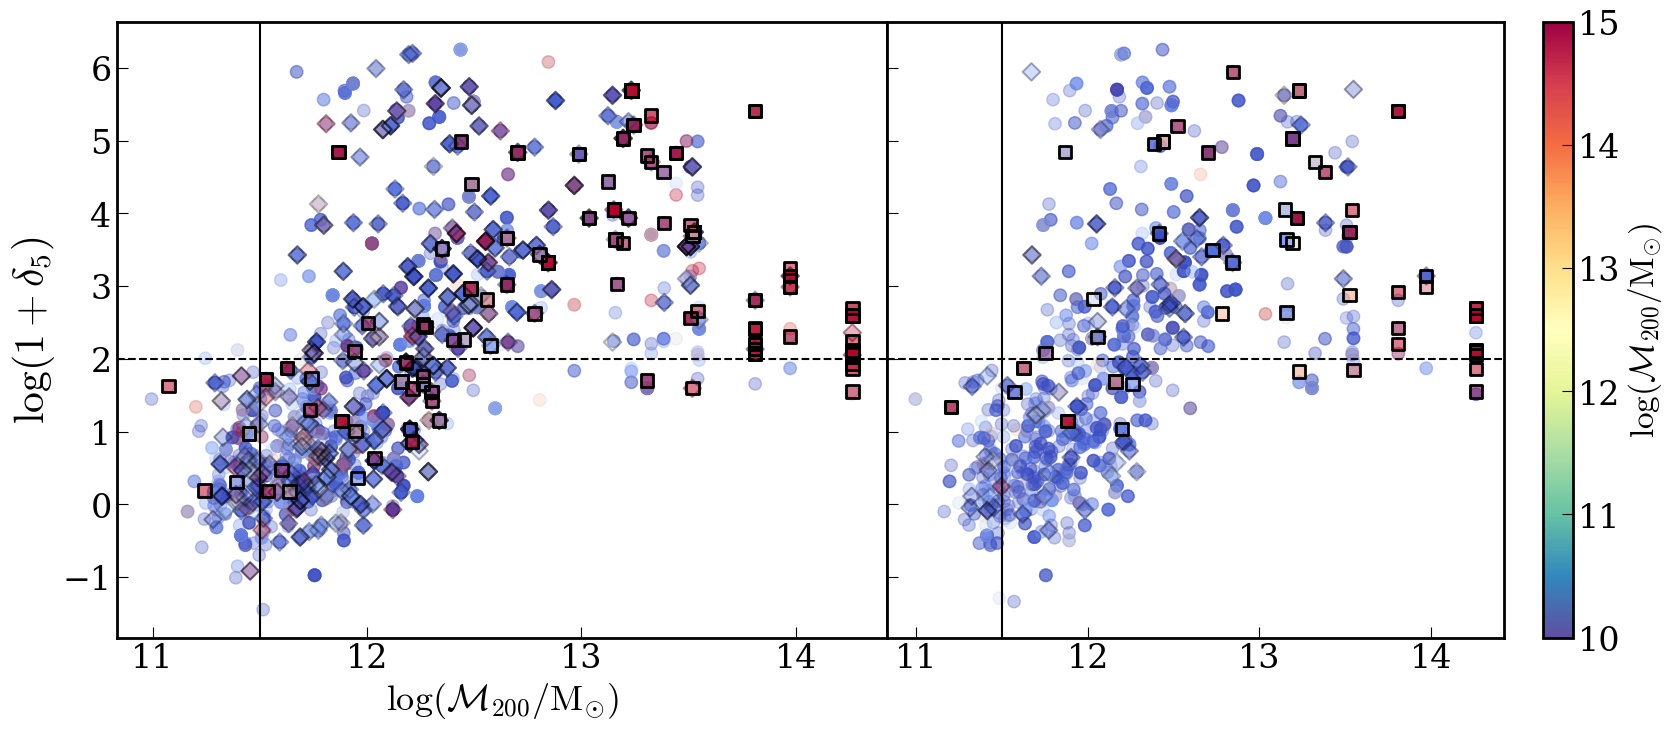

In [43]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.0,0.46,0.005],sharey=True)

all_gal_tree =  KDTree(gls.sub.SubhaloPos[all_gal,:]) 

for k in range(3):
    mst_b = np.array(gls.sub.mst[llg[k]])
    ssfr_b = np.array(gls.sub.ssfr[llg[k]])
    m200_b = gls.hst.group_m200[llh[k]]

    #m200_dhp = gls.hst.group_m200[gls.sub.SubhaloGrNr[dhp[k]][red]]
    dw_b1 = np.where((m200_b<11.5)&(mst_b<8.5))[0]
    dw_b2 = np.where((m200_b<11.5)&(mst_b<9.5)&(mst_b>=8.5))[0]
    print(len(dw_b1),len(dw_b2))

    m200_mdb = gls.hst.group_m200[gls.sub.SubhaloGrNr[mdb[k]]]

    llr_b = []
    for j in mdb[k]:
        dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=6)
        dist0 *= dconv
        llr_b.append(0.2387324146*6/dist0[-1]**3)
    llr_b = np.log10(llr_b) - np.log10(0.142904)
    dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
    
    ax[0].scatter(m200_mdb[dw_b1],llr_b[dw_b1],c=dsfms_b[dw_b1],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 
    ax[2].scatter(m200_mdb[dw_b2],llr_b[dw_b2],c=dsfms_b[dw_b2],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80) 

    if k==1:
        ax[0].scatter(m200_mdb[dw_b1],llr_b[dw_b1],c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.25,s=80)  
        ax[2].scatter(m200_mdb[dw_b2],llr_b[dw_b2],c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.25,s=80)  

    if k==2:
        ax[0].scatter(m200_mdb[dw_b1],llr_b[dw_b1],c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80)  
        ax[2].scatter(m200_mdb[dw_b2],llr_b[dw_b2],c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80)  
    
for j in [1,3]:
    ax[j-1].axvline(11.5,color='black')
    ax[j-1].axhline(2,color='black',ls='--')
    ax[j].set_axis_off()

ax[0].set_ylabel(r'$log(1+\delta_5)$',fontsize=30)
ax[0].set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax[1].set_xlabel(r'$log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=15),cmap=mcm.Spectral_r), ax=ax[2], orientation='vertical',label=r'$log(\mathcal{M}_{200}/M_{\odot})$')

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)


92


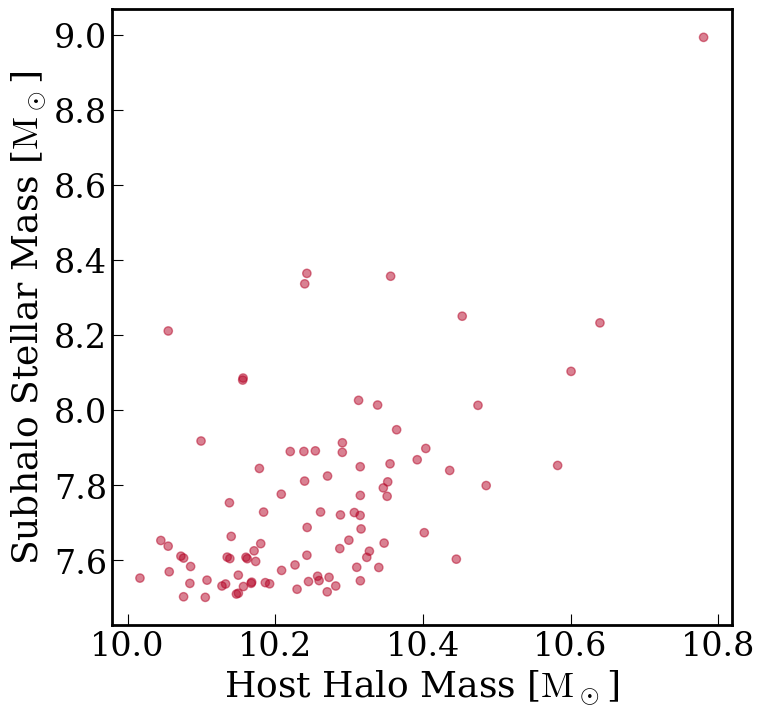

In [10]:
fig,ax=plt.subplots(figsize=(8,8),sharey=True)

m200_b = gls.hst.group_m200[llh[0]]
dhp_b = gls.sub.SubhaloGrNr[dhp[0]]
mst_b = gls.sub.mst[llg[0]]
ssfr_b = gls.sub.ssfr[llg[0]]
dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
selc = np.where((dsfms_b<-1)&(m200_b<11))[0]
cand = np.array(llg[0])[selc]
print(len(selc))

ax.scatter(m200_b[selc],mst_b[selc],c=dsfms_b[selc],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5,marker='o') 

ax.set_xlabel('Host Halo Mass [$M_\odot$]',fontsize=26)
ax.set_ylabel('Subhalo Stellar Mass [$M_\odot$]',fontsize=26)
plt.subplots_adjust(wspace=0.0)

In [ ]:
fig,ax=plt.subplots(figsize=(10,8))

mh_bins = np.linspace(11.5,14.5,8)
mh_bw = 0.5*(mh_bins[1]-mh_bins[0])

m200_dhp_vin = gls.hst.group_m200[dhp_b[selc[np.where(v<0)[0]]]]
m200_dhp_vout = gls.hst.group_m200[dhp_b[selc[np.where(v>=0)[0]]]]
    
bin_sat, bin_edg = np.histogram(m200_dhp_vin,bins=mh_bins)
ax.step(bin_edg[:-1]+mh_bw,bin_sat,color='darkorange',lw=3,where='mid',label=r'$v_r<0$')

bin_sat, bin_edg = np.histogram(m200_dhp_vout,bins=mh_bins)
ax.step(bin_edg[:-1]+mh_bw,bin_sat,color='purple',lw=3,where='mid',label=r'$v_r>0$')

ax.legend(loc='best',fontsize=26,frameon=True)
ax.set_ylabel(r'$Number$',fontsize=32)
ax.set_xlabel(r'$Nearest\ Massive\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('quench_infalls.pdf',bbox_inches='tight')